In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pickle
import glob
import sys

# Make local code importable (expects Code/compute_session_alignment.py)
sys.path.append('./Code/')
import compute_session_alignment

from collections import Counter
from joblib import Parallel, delayed

# ---------------------------------------------------------------------
# Decoders: mean‐template variants
# ---------------------------------------------------------------------
def letter_decoding_mean(x_train, x_test, y_train, y_test, shuffle=False):
    """
    Mean‐template decoding that compares per‐class mean TEST activity to
    per‐class mean TRAIN templates using cosine similarity, but counts
    accuracy at the **class‐mean** level (i.e., 1 correct per class).

    Args
    ----
    x_train, x_test : array (trials × time × features) BEFORE windowing.
    y_train, y_test : array (trials,) with discrete class labels.
    shuffle         : bool, if True shuffles y labels for a null/control.

    Returns
    -------
    score_matrix : (n_win × n_win) array of counts (not normalized).
                   Entry (ti, tj) = number of classes correctly predicted
                   when training a template at window ti and testing on
                   class means at window tj.
    n_classes    : int, number of unique classes present in training labels.
    """
    
    n_win = len(window_ranges)
    score_matrix = np.zeros((n_win, n_win))

    # Copy/alias labels (already integers/strings)
    y_train_encoded = y_train
    y_test_encoded  = y_test
    class_labels    = [0,1] #np.unique(y_train_encoded)

    # Average activity in sliding windows and baseline‐correct by FIX bins
    #print((x_train.shape,x_test.shape),flush=True)
    xTTrain_all = [np.mean(x_train[:, start:end, :], axis=1) #- np.mean(x_train[:, 0:4, :], axis=1)
                   for (start, end) in window_ranges]
    xTTest_all  = [np.mean(x_test[:, start:end, :], axis=1)  #- np.mean(x_test[:, 0:4, :], axis=1)
                   for (start, end) in window_ranges]

    if shuffle:
        # Shuffle labels independently for train/test for a conservative null
        np.random.shuffle(y_train_encoded)
        np.random.shuffle(y_test_encoded)

    all_templates = []  # keep templates from each TRAIN window (for inspection)
    for ti, xTTrain in enumerate(xTTrain_all):
        for tj, xTTest in enumerate(xTTest_all):
            if(ti==tj):
                # --- TRAIN: build one mean template per class (in window ti)
                templates = []
                for c in class_labels:
                    class_indices = np.where(y_train_encoded == c)[0]
                    template = np.mean(xTTrain[class_indices], axis=0)
                    templates.append(template)
                templates = np.array(templates)  # (n_classes × n_features)

                if tj == 0:
                    all_templates.append(templates)

                # --- TEST: compare per‐class MEAN test activity to templates
                correct = 0
                for c_idx, c in enumerate(class_labels):
                    test_indices = np.where(y_test_encoded == c)[0]
                    if len(test_indices) == 0:
                        continue

                    # mean vector for THIS class/window
                    test_vec = np.mean(xTTest[test_indices], axis=0)

                    # Cosine similarity to each template -> scalars
                    corrs = [
                        float(np.dot(test_vec, tpl) / (np.linalg.norm(test_vec) * np.linalg.norm(tpl) + 1e-8))
                        for tpl in templates
                    ]

                    # tie-break
                    if len(corrs) == 2 and np.isclose(corrs[0], corrs[1]):
                        predicted_class_idx = np.random.choice([0, 1])
                    else:
                        predicted_class_idx = int(np.argmax(corrs))

                    predicted_class = class_labels[predicted_class_idx]
                    if predicted_class == c:
                        correct += 1
                        

            score_matrix[ti, tj] = correct  # raw count (not %)
            
    return score_matrix, 2, #len(class_labels)

In [16]:
units = np.load('../Data/units.npy',allow_pickle=True)
units[6][0]

array(['uAHL1_0', 'uAHL1_4', 'uAHL1_5', 'uAHL2_0', 'uAHL3_0', 'uAHL4_1',
       'uAHL5_0', 'uAHL7_1', 'uAHL7_4', 'uAL8_17', 'uAL8_19', 'uECL3_14',
       'uPHL2_3', 'uPHR1_1', 'uPHR3_5', 'uPHR5_1', 'uPHR6_2', 'uPHR6_4',
       'uPHR6_5', 'uPHR6_6', 'uPHR6_7', 'uPHR6_8', 'uPHR6_9', 'uPHR7_16',
       'uPHR7_2', 'uPHR7_3', 'uPHR7_8'], dtype=object)

In [17]:
completeBinned = np.load('../Data/binned.npy', allow_pickle=True)
completeBinned[1].shape

(99, 16, 16)

In [18]:
letters        = np.load('../Data/letters.npy')
uniqueLetters = np.array([p for p in np.unique(letters) if p not in ['Q', 'W', 'X']])
uniqueLetters

array(['B', 'C', 'D', 'F', 'G', 'H', 'K', 'L', 'N', 'P', 'R', 'S', 'T',
       'V', 'Z'], dtype='<U1')

In [19]:
subj_ses = np.load('../Data/subjs_sep.npy',allow_pickle=True)
len(subj_ses)

35

In [20]:
from copy import deepcopy
NPC_TO_ALIGN = 5
# ---------------------------------------------------------------------
# Shared/static variables (loaded once)
# ---------------------------------------------------------------------
# NOTE: The following variables are referenced later. Make sure they are
# defined prior to calling functions that use them.

# Load all data (paths assume ../Data/ exists)
probes         = np.load('../Data/probes.npy')
subj           = np.load('../Data/subjs.npy')
subj_ses       = np.load('../Data/subjs_sep.npy', allow_pickle=True)
inout          = np.load('../Data/in.npy')
letters        = np.load('../Data/letters.npy')
letters_ses    = np.load('../Data/letters_sep.npy', allow_pickle=True)
probes_ses     = np.load('../Data/probes_sep.npy', allow_pickle=True)
units          = np.load('../Data/units.npy',allow_pickle=True)

# Subject/session metadata
sses          = [s[0] for s in subj_ses]
uniqueSub     = np.unique(sses)

# Letters (exclude rarely used or unwanted letters)
uniqueLetters = np.array([p for p in np.unique(letters) if p not in ['Q', 'W', 'X']])
n_labels      = len(uniqueLetters)

# Sliding windows: 4 bins wide, sliding by 1 bin (29 positions)
window_ranges = [(i, i + 1) for i in range(16)]

# ---------------------------------------------------------------------
# One permutation "trial": align, project, decode (for one letter)
# ---------------------------------------------------------------------
t1 = 2
t2 = 16
def single_trial(ktrial, letter_index):
    retry = 0 
    ok = False
    while not ok:
        maskSub = [subj_ses[i][0]!=outSub for i in range(len(subj_ses))]
        completeBinned = np.load('../Data/binned.npy', allow_pickle=True)
        completeBinned = completeBinned[maskSub]
        #Counter(subj)

        data = []
        train_test_labels = []

        Y      = [np.array([[1 if u in letterString else 0 for u in uniqueLetters] for letterString in ls], dtype=int)
                 for ls in letters_ses[maskSub]]
        
        Yprobe = [np.array([[1 if u in letterString else 0 for u in uniqueLetters] for letterString in ls], dtype=int)
                 for ls in probes_ses[maskSub]]
         
        maskSET_TEST  = [np.sum(yi,axis=1)>0 for yi in Y]
        maskSET_TRAIN = [np.sum(yi,axis=1)>0 for yi in Y]
        
        #maskSET_TEST  = [np.sum(yi*yp,axis=1)>=0 for (yi,yp) in zip(Y,Yprobe)]
        #maskSET_TRAIN = [np.sum(yi*yp,axis=1)>=0 for (yi,yp) in zip(Y,Yprobe)]
        #print(maskSET_TEST,flush=True)
        
        units =  np.load('../Data/units.npy', allow_pickle=True)
        units = units[maskSub]

        all_maskU = []
        newcompleteBinned = []
        newY = []
        newMaskSET_TEST  = []
        newMaskSET_TRAIN = []
        for i in range(len(completeBinned)):
            
            maskU = [list(np.where(['ECR' in ui for ui in units[i][0]])[0])+
            #list(np.where(['AHL' in ui for ui in units[i][0]])[0])+
            #list(np.where(['PHR' in ui for ui in units[i][0]])[0])+
            list(np.where(['ECL' in ui for ui in units[i][0]])[0])][0]
            
            
            bst = completeBinned[i]
            #print(bst.shape,flush=True)
            #print(maskU,flush=True)
            
            bst = bst[:,maskU]
            bst = np.transpose(bst, (1, 2, 0))
            if len(bst) >= NPC_TO_ALIGN:
                newcompleteBinned.append(completeBinned[i])
                newY.append(Y[i])
                newMaskSET_TEST.append(maskSET_TEST[i])
                newMaskSET_TRAIN.append(maskSET_TRAIN[i])
                tt_label  = np.random.uniform(0, 1, len(bst[0][0])) > 0.5
                #tt_label = np.zeros(len(bst[0][0]))
                #tt_label[np.random.choice(np.arange(len(tt_label)),
                #                          size=1,
                #                          replace=False)] = 1

                condition = Y[i][:, letter_index]

                mask    = np.logical_and(tt_label == 0,condition>-1)
                timeB   = np.arange(len(bst[0])) * 0.250
                session = {
                    'response' : bst[:,:,mask],#bst[:, :, tt_label == 0],
                    'condition': condition[mask],#condition[tt_label == 0],
                    'time'     : timeB
                }
                data.append(session)
                all_maskU.append(maskU)
                train_test_labels.append(tt_label)


        pars = {'alignment': {'nPCs_align': NPC_TO_ALIGN, 'cond_contrast': (1, 0)}, 'align_proj': {'condition_vars': []}}

        D_align, D_cond_avg_proj_align, align_stats = compute_session_alignment.compute_session_alignment_CONTRAST_2BIAS(data, [], pars,t1,t2)

        Z_align = deepcopy(D_align)
        #print(len(all_maskU),len(train_test_labels),len(newcompleteBinned),len(D_align),newcompleteBinned[0].shape,flush=True)
        X = np.concatenate([Z_align[i]['response'] for i in range(len(Z_align))], axis=2)
        #X = X[accepted_components]
        projected_X = [
            np.transpose(newcompleteBinned[sesID][:,all_maskU[sesID]], (0, 2, 1)) @ D_align[sesID]['U'] + D_align[sesID]['bias'] #[:, accepted_components]
            for sesID in range(len(newcompleteBinned))
        ]

        #print(len(projected_X),flush=True)
        X_train = [projected_X[i][np.logical_and(train_test_labels[i] == 0, newMaskSET_TRAIN[i])] for i in range(len(train_test_labels))]
        X_test  = [projected_X[i][np.logical_and(train_test_labels[i] == 1, newMaskSET_TEST[i])] for i in range(len(train_test_labels))]
        Y_train = [newY[i][np.logical_and(train_test_labels[i] == 0, newMaskSET_TRAIN[i]), letter_index] for i in range(len(train_test_labels))]
        Y_test  = [newY[i][np.logical_and(train_test_labels[i] == 1, newMaskSET_TEST[i]), letter_index] for i in range(len(train_test_labels))]
        #Y_probe_test  = [Yprobe[i][train_test_labels[i] == 1, letter_index] for i in range(len(train_test_labels))]

        X_train = np.concatenate(X_train, axis=0)
        X_test  = np.concatenate(X_test, axis=0)
        Y_train = np.concatenate(Y_train, axis=0)
        Y_test  = np.concatenate(Y_test, axis=0)
        
        if( (np.sign(np.mean(X_train[Y_train==1,t1:t2]))*np.sign(np.mean(X_train[Y_train==0,t1:t2])))<0 ):
            ok = True
        else:
            print('retry attempt: ',retry,flush=True)
            retry += 1
    
    
    MW,SUM_IT = letter_decoding_mean(
            X_train,
            X_test,
            Y_train,
            Y_test,
            shuffle=False
        )

    #return [D_align[sesID]['U'] + D_align[sesID]['bias'] for sesID in range(len(completeBinned))]
    return MW,SUM_IT

In [21]:
import importlib
importlib.reload(compute_session_alignment)
# ---------------------------------------------------------------------
# Outer loops: run multiple rounds and save per‐letter maps
# ---------------------------------------------------------------------
print(np.unique(subj))
for outSub in [0]: #np.unique(subj):
    print(outSub)
    for qqq in range(20):
        print(qqq)
        all_Letters = []
        for letter_index in range(15):  # first 15 letters from uniqueLetters
            # Run many permutations in parallel and aggregate
            #print(letter_index)
            c = True
            cc = 0 
            while c:
                try:
                    results = Parallel(n_jobs=-1, verbose=0)(
                    delayed(single_trial)(ktrial, letter_index) for ktrial in range(50)
                    )
                    allMW  = [res[0] for res in results if res is not None]
                    allSUM = [res[1] for res in results if res is not None]
                    mean_MW = np.sum(allMW, axis=0) / np.sum(allSUM)
                    all_Letters.append(mean_MW)
                    c = False
                except:
                    cc +=1
                    #print('Error')
                    if(cc >50):
                        continue

        np.save(f'../single_letter_EC_'+str(qqq)+'.npy', all_Letters)

[40 43 44 45 47 53 57 58 61 63 64]
0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [24]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patheffects as pe

# ------------------------ load helpers (no shuffling) ------------------------
def load_letter_acc(area_prefix, n_runs=20, n_letters=15):
    stacks = []
    for k in range(n_runs):
        all_Letters = np.load(f'../single_letter_{area_prefix}_{k}.npy')  # (n_letters, n_steps, n_steps)
        diag_per_letter = [np.diag(all_Letters[li]) for li in range(n_letters)]
        stacks.append(np.array(diag_per_letter))
    return np.array(stacks)  # (n_runs, n_letters, n_steps)

def load_letter_acc_all(n_runs=50, n_letters=15):
    stacks = []
    for k in range(n_runs):
        all_Letters = np.load(f'../single_letter_{k}.npy')
        diag_per_letter = [np.diag(all_Letters[li]) for li in range(n_letters)]
        stacks.append(np.array(diag_per_letter))
    return np.array(stacks)

acc_HYP = load_letter_acc("HYP")
acc_AMY = load_letter_acc("AMY")
acc_ENT = load_letter_acc("EC")
acc_ALL = load_letter_acc_all()

# ------------------------ pick target letters ------------------------
target_letters = ['F','B','C','G','V','D','N','R']
L    = len(target_letters)
idxs = [np.where(t == uniqueLetters)[0][0] for t in target_letters]

# ------------------------ compute last-step accuracies (no flattening) ------------------------
T1, T2 = 2, 16
T = T2 - T1

def compute_last_true(letter_acc, letter_indices, T1=4, T2=32):
    last_true = np.array([
        np.cumsum(letter_acc[:, i, T1:T2], axis=-1)[:, -1] / (T2 - T1)
        for i in letter_indices
    ])  # (L, n_runs)
    return [last_true[row_ix] for row_ix in range(last_true.shape[0])]

data_HYP = compute_last_true(acc_HYP, idxs, T1=T1, T2=T2)
data_AMY = compute_last_true(acc_AMY, idxs, T1=T1, T2=T2)
data_ENT = compute_last_true(acc_ENT, idxs, T1=T1, T2=T2)
data_ALL = compute_last_true(acc_ALL, idxs, T1=T1, T2=T2)

# Precompute ALL medians (one value per letter)
all_medians = np.array([np.median(arr) for arr in data_ALL])  # (L,)


Pairwise permutation tests on medians (FDR-corrected):
HYP vs AMY: Δmedian=0.004161, raw p_perm=0.6803, FDR=0.8545, significant=False
HYP vs ENT: Δmedian=-0.003, raw p_perm=0.8545, FDR=0.8545, significant=False
AMY vs ENT: Δmedian=-0.007161, raw p_perm=0.8087, FDR=0.8545, significant=False


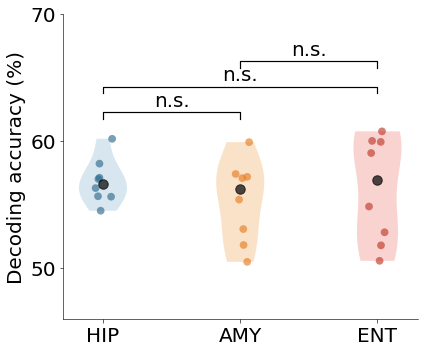

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from statsmodels.stats.multitest import fdrcorrection

# -------------------------------------------------------------------
# Assuming you already have:
#   data_HYP, data_AMY, data_ENT  = np.ndarray with shape (..., trials)
# and you want to average over the last axis to get a single value per subject.
# If you already have vals_* directly, comment the next 3 lines.
# -------------------------------------------------------------------
vals_AMY = np.mean(data_AMY, axis=-1)
vals_HYP = np.mean(data_HYP, axis=-1)
vals_ENT = np.mean(data_ENT, axis=-1)

# ------------------------------------------------------
# vals_HYP, vals_AMY, vals_ENT are 1D arrays of length L
# ------------------------------------------------------

mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.family": "sans-serif",
    "axes.linewidth": 0.6,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.major.width": 0.6, "ytick.major.width": 0.6
})

# Colors
COL_HYP, COL_HYP_L = "#2F6C8E", "#BFD6E6"   # blue
COL_AMY, COL_AMY_L = "#E67E22", "#F8CFA6"   # orange
COL_ENT, COL_ENT_L = "#C0392B", "#F5B7B1"   # red

data = [vals_HYP, vals_AMY, vals_ENT]
labels = ["HIP", "AMY", "ENT"]
positions = np.arange(3)

fig, ax = plt.subplots(figsize=(6,5))
FS = 20
rng = np.random.default_rng(1234)

# ---------- Violin helper ----------
def add_violin(ax, datas, positions, faces, edges, width=0.35, alpha=0.6):
    for d, p, fc, ec in zip(datas, positions, faces, edges):
        vp = ax.violinplot([d], positions=[p], widths=width,
                           showextrema=False, showmedians=False, showmeans=False)
        for b in vp["bodies"]:
            b.set_facecolor(fc)
            b.set_linewidth(1.0)
            b.set_alpha(alpha)

# ---------- Draw violins ----------
add_violin(ax, data, positions,
           [COL_HYP_L, COL_AMY_L, COL_ENT_L],
           [COL_HYP,   COL_AMY,   COL_ENT])

# ---------- Scatter points ----------
for vals, p, col in zip([vals_HYP, vals_AMY, vals_ENT],
                        positions,
                        [COL_HYP, COL_AMY, COL_ENT]):
    jitter = rng.uniform(-0.07, 0.07, size=len(vals))
    ax.scatter(np.full_like(vals, p) + jitter, vals,
               s=60, color=col, alpha=0.65, edgecolor="none", zorder=3)

# ---------- Median markers ----------
ax.scatter(positions,
           [np.median(vals_HYP), np.median(vals_AMY), np.median(vals_ENT)],
           s=90, color="black", zorder=4, alpha=0.7)

# ======================================================
#       PERMUTATION TEST ON MEDIAN DIFFERENCES
# ======================================================

def permutation_test_median(a, b, n_perm=10000, rng=None):
    """
    Two-sided permutation test on the difference in medians between a and b.
    H0: median(a) == median(b)
    H1: median(a) != median(b)
    """
    a = np.asarray(a)
    b = np.asarray(b)
    if rng is None:
        rng = np.random.default_rng()

    # Observed difference in medians
    observed = np.median(a) - np.median(b)

    # Null distribution via label shuffling
    pooled = np.concatenate([a, b])
    n_a = len(a)

    perm_stats = np.empty(n_perm)
    for i in range(n_perm):
        rng.shuffle(pooled)
        perm_a = pooled[:n_a]
        perm_b = pooled[n_a:]
        perm_stats[i] = np.median(perm_a) - np.median(perm_b)

    # Two-sided p-value
    p = (np.sum(np.abs(perm_stats) >= np.abs(observed)) + 1) / (n_perm + 1)
    return observed, p

# Pairwise comparisons (indices correspond to positions on x-axis)
pairs = [
    (0, 1, "HYP vs AMY", vals_HYP, vals_AMY),
    (0, 2, "HYP vs ENT", vals_HYP, vals_ENT),
    (1, 2, "AMY vs ENT", vals_AMY, vals_ENT),
]

pair_coords = []
raw_pvals = []
obs_stats = []

rng_perm = np.random.default_rng(1234)

for x1, x2, name, a, b in pairs:
    stat, p = permutation_test_median(a, b,
                                      n_perm=10000,
                                      rng=rng_perm)
    obs_stats.append(stat)
    raw_pvals.append(p)
    pair_coords.append((x1, x2))

# FDR correction on permutation p-values
reject, p_fdr = fdrcorrection(raw_pvals, alpha=0.05)

print("\nPairwise permutation tests on medians (FDR-corrected):")
for (x1, x2, name, _, _), stat, p_raw, p_adj, sig in zip(
        pairs, obs_stats, raw_pvals, p_fdr, reject):
    print(f"{name}: Δmedian={stat:.4g}, raw p_perm={p_raw:.4g}, "
          f"FDR={p_adj:.4g}, significant={sig}")

# ---------- Significance bar helpers ----------
def add_sig_bar(ax, x1, x2, y, text):
    ax.plot([x1, x1, x2, x2],
            [y,  y+0.005, y+0.005, y],
            color='black', linewidth=1.2)
    ax.text((x1+x2)/2, y+0.007, text,
            ha='center', va='bottom', fontsize=FS)

def p_to_star(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "n.s."

# ---------- Add permutation-based stars ----------
y_max = max(map(max, [vals_HYP, vals_AMY, vals_ENT]))
offset = 0.02
current_y = y_max + 0.01

for (x1, x2), p_adj in zip(pair_coords, p_fdr):
    star = p_to_star(p_adj)
    add_sig_bar(ax, x1, x2, current_y, star)
    current_y += offset

# ======================================================
#               AXIS COSMETICS & SAVE
# ======================================================

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=FS)
ax.set_ylabel("Decoding accuracy (%)", fontsize=FS)
ax.set_ylim(0.46, 0.68)

ax.set_yticks([0.5, 0.6, 0.7])
ax.set_yticklabels([50, 60, 70])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=FS)

plt.tight_layout()
fig.savefig("../figure_letters_HYP_AMY_ENT_permMedian.svg", dpi=200)
plt.show()